<a href="https://colab.research.google.com/github/stnoeranindya-sys/pds_python/blob/main/machinelearning_St_Noer_Anindya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Library
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Membuat DataFrame dari data yang diberikan
data = {
    'Partisipan': np.arange(1, 11),
    'Pengeluaran Makanan': [50, 40, 60, 55, 45, 65, 70, 75, 80, 90],
    'Pengeluaran Transportasi': [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
    'Berat Badan': [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]
}

df = pd.DataFrame(data)

# Memisahkan variabel independen dan dependen
X = df[['Pengeluaran Makanan', 'Pengeluaran Transportasi']]
y = df['Berat Badan']

# Menambahkan kolom konstanta untuk intercept
X = sm.add_constant(X)

# Membangun Model Regresi
model = sm.OLS(y, X)
results = model.fit()

#Menampilkan hasil
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:            Berat Badan   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     234.6
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           3.85e-07
Time:                        00:36:32   Log-Likelihood:                -18.626
No. Observations:                  10   AIC:                             43.25
Df Residuals:                       7   BIC:                             44.16
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.graph_objects as go

data = {
    "Partisipan": np.arange(1, 11),
    "Peng Makanan": [50, 40, 60, 55, 45, 65, 70, 75, 80, 990],
    "Peng Transportasi": [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
    "Berat Badan": [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]
}
df = pd.DataFrame(data)

X = df[["Peng Makanan", "Peng Transportasi"]]
y = df["Berat Badan"]

X_model = sm.add_constant(X)
model = sm.OLS(y, X_model)
results = model.fit()

print("\n")
print("=" * 70)
print(" HASIL REGRESI LINEAR BERGANDA")
print("=" * 70)
print(results.summary())

intercept = results.params["const"]
coef_makanan = results.params["Peng Makanan"]
coef_transportasi = results.params["Peng Transportasi"]
r_squared = results.rsquared
adjusted_r_squared = results.rsquared_adj

persamaan = (
    f"Ŷ = {intercept:.3f}"
    f" + ({coef_makanan:.3f}) X1"
    f" + ({coef_transportasi:.3f}) X2"
)
print("\n")
print("=" * 70)
print(" PERSAMAAN REGRESI")
print("=" * 70)
print(persamaan)
print(f"\nR2 = {r_squared:.4f}")
print(f"Adjusted R2 = {adjusted_r_squared:.4f}")

df["Prediksi"] = results.predict(X_model)
print("\n")
print("=" * 70)
print(" DATA AKTUAL & PREDIKSI")
print("=" * 70)
print(
    df[[
        "Partisipan",
        "Peng Makanan",
        "Peng Transportasi",
        "Berat Badan",
        "Prediksi"
    ]].round(2)
)

x1 = np.linspace(
    df["Peng Makanan"].min(),
    df["Peng Makanan"].max(),
    40
)
x2 = np.linspace(
    df["Peng Transportasi"].min(),
    df["Peng Transportasi"].max(),
    40
)
X1, X2 = np.meshgrid(x1, x2)

Y = intercept + coef_makanan * X1 + coef_transportasi * X2

fig = go.Figure()
fig.add_trace(
    go.Scatter3d(
        x=df["Peng Makanan"],
        y=df["Peng Transportasi"],
        z=df["Berat Badan"],
        mode="markers",
        marker=dict(size=7, color="red", opacity=0.9),
        name="Data Aktual",
        text=[f"Partisipan {p}" for p in df["Partisipan"]],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Peng. Makanan: %{x}<br>"
            "Peng. Transportasi: %{y}<br>"
            "Berat Badan: %{z}"
            "<extra></extra>")))

fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Y,
        opacity=0.60,
        colorscale="Viridis",
        name="Regression Plane",
        hovertemplate=(
            "Peng. Makanan: %{x:.2f}<br>"
            "Peng. Transportasi: %{y:.2f}<br>"
            "Prediksi Y: %{z:.2f}"
            "<extra></extra>")))

fig.update_layout(
    title={
        "text": (
            "REGRESI LINEAR BERGANDA 3D"
            "<br>"
            f"<sup>{persamaan} | R2 = {r_squared:.3f}</sup>"
        ),
        "x": 0.5
    },
    scene={
        "xaxis": {"title": "Pengeluaran Makanan (X1)"},
        "yaxis": {"title": "Pengeluaran Transportasi (X2)"},
        "zaxis": {"title": "Berat Badan (Y)"}
    },
    width=1000,
    height=750,
    margin={"l": 0, "r": 0, "b": 0, "t": 100},
    legend={"x": 0.02, "y": 0.98})

fig.show()



 HASIL REGRESI LINEAR BERGANDA
                            OLS Regression Results                            
Dep. Variable:            Berat Badan   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     42.50
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           0.000121
Time:                        00:37:14   Log-Likelihood:                -26.846
No. Observations:                  10   AIC:                             59.69
Df Residuals:                       7   BIC:                             60.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const

In [3]:
import numpy as np
from scipy import stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])


result = stats.normaltest(data)

test_statistic = result.statistic
p_value = result.pvalue

print("Test Statistic:", test_statistic)
print("p-value:", p_value)

Test Statistic: 14.751506680126681
p-value: 0.0006262547379134614


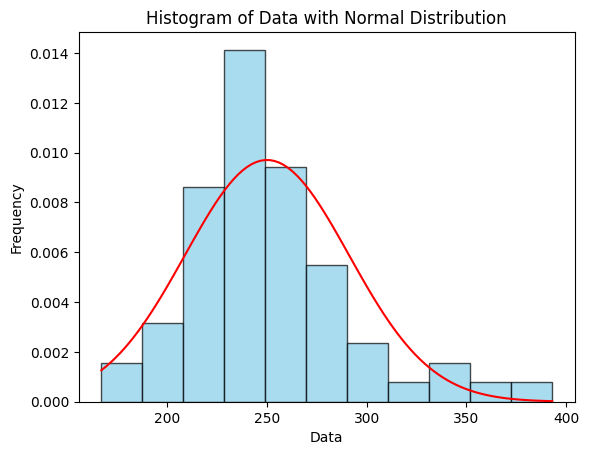

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])

plt.hist(data, bins='auto', density=True, alpha=0.7, color='skyblue', edgecolor='black')

mu, std = np.mean(data), np.std(data)
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.norm.pdf(x, mu, std)
plt.plot(x, y, color='red')

plt.title('Histogram of Data with Normal Distribution')
plt.xlabel('Data')
plt.ylabel('Frequency')

plt.show()

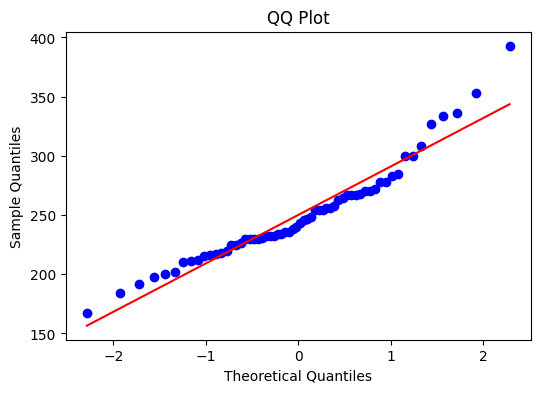

In [5]:
plt.figure(figsize=(6, 4))
stats.probplot(data, dist="norm", plot=plt)

plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.show()
# sumber data : https://www.statext.com/practice/NormalityTest02.php

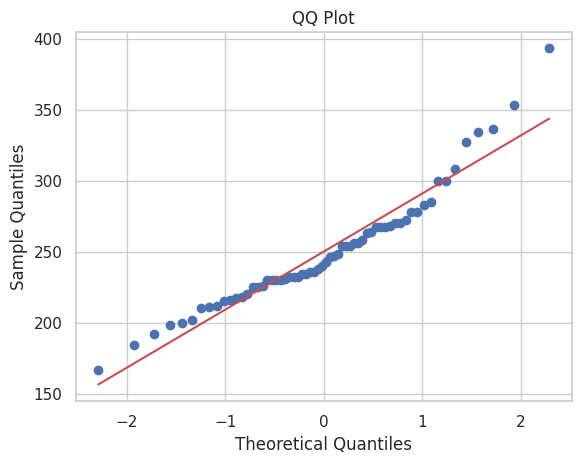

In [6]:
import numpy as np
import seaborn as sns
import scipy.stats as stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])

sns.set(style="whitegrid")
stats.probplot(data, dist="norm", plot=sns.mpl.pyplot)

sns.mpl.pyplot.title('QQ Plot')
sns.mpl.pyplot.xlabel('Theoretical Quantiles')
sns.mpl.pyplot.ylabel('Sample Quantiles')

sns.mpl.pyplot.show()

In [7]:
import numpy as np
from scipy import stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])

ks_statistic, ks_pvalue = stats.kstest(data, 'norm')
print("Kolmogorov-Smirnov Test:")
print("Test Statistic:", ks_statistic)
print("p-value:", ks_pvalue)

Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0


In [8]:
sw_statistic, sw_pvalue = stats.shapiro(data)
print("\nShapiro-Wilk Test:")
print("Test Statistic:", sw_statistic)
print("p-value:", sw_pvalue)


Shapiro-Wilk Test:
Test Statistic: 0.9385651298228793
p-value: 0.0038978835421956235


In [9]:
jb_statistic, jb_pvalue = stats.jarque_bera(data)
print("\nJarque-Bera Test:")
print("Test Statistic:", jb_statistic)
print("p-value:", jb_pvalue)


Jarque-Bera Test:
Test Statistic: 17.253454012480432
p-value: 0.00017925037145018067


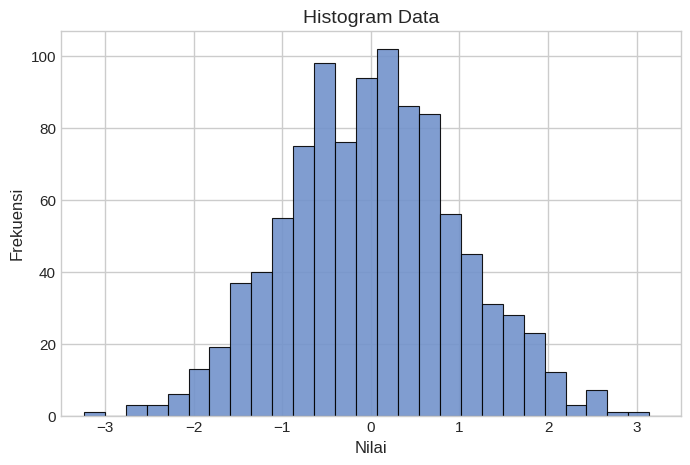

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
data = np.random.normal(loc=0.0, scale=1.0, size=1000)

plt.figure(figsize=(8, 5))
plt.hist(data,
         bins=30,               # Mengatur jumlah batang
         color='#7293cb',       # Warna isi batang biru keabuan (mirip gambar)
         edgecolor='black',     # Warna garis tepi batang hitam tipis
         linewidth=0.8,         # Ketebalan garis tepi
         alpha=0.9)             # Transparansi warna

# Menambahkan judul dan label sumbu
plt.title('Histogram Data', fontsize=14, fontweight='medium')
plt.xlabel('Nilai', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Mengatur batas sumbu x agar sesuai dengan data normal (sekitar -3 hingga 3)
plt.xlim(-3.5, 3.5)

# Menampilkan grafik
plt.show()